In [12]:
# Import core data manipulation, machine learning, and visualization libraries
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the cleaned dataset containing car specifications and pricing
df = pd.read_csv("final_cleaned_data.csv")

# Apply log transformation (log1p) to car prices to handle right-skewness and stabilize variance
df["log_price"] = np.log1p(df["cars_prices"]) 

# Separate features (X) and target variable (y), dropping original and transformed price from features
y = df["log_price"]
X = df.drop(columns=["log_price", "cars_prices"])

# Split the dataset into 80% training and 20% testing sets using a fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Identify numerical columns for numerical preprocessing
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

# Identify categorical text columns for encoding
categorical_features = X.select_dtypes(
    include=["object"]
).columns

# Pipeline for numerical features: fill missing values with the column median
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Pipeline for categorical features: fill missing values with most frequent value and one-hot encode
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

# Combine numeric and categorical pipelines into a unified preprocessing column transformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [13]:
# Assemble the baseline Random Forest pipeline by chaining the preprocessor and the regressor
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the baseline model on training data and generate price predictions on test data
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Calculate Mean Absolute Error (MAE) - average magnitude of prediction errors
rf_mae = mean_absolute_error(y_test, rf_pred)

# Calculate Root Mean Squared Error (RMSE) - penalizes larger prediction errors more heavily
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

# Calculate R-squared (R²) - proportion of variance explained by the baseline model
rf_r2 = r2_score(y_test, rf_pred)

# Print baseline evaluation metrics for comparison
print("RFRModel MAE:", rf_mae)
print("RFRModel RMSE:", rf_rmse)
print("RFRModel R²:", rf_r2)


RFRModel MAE: 0.1512044092376502
RFRModel RMSE: 0.21246058527714903
RFRModel R²: 0.950165485004328


In [ ]:
# Define hyperparameter search grid to explore different tree depths, splits, and feature subsets
param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

# Set up Randomized Search with 5-fold cross-validation targeting lowest RMSE across 20 iterations
rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Run hyperparameter search on the training dataset and retrieve the best-performing model
rf_search.fit(X_train, y_train)
rf_search.best_params_
-rf_search.best_score_
best_model = rf_search.best_estimator_

# Predict car prices on the unseen test dataset using the fine-tuned model
tuned_pred = best_model.predict(X_test)

# Calculate MAE for the tuned model
tuned_mae = mean_absolute_error(
    y_test,
    tuned_pred
)

# Calculate RMSE for the tuned model
tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

# Calculate R-squared (R²) for the tuned model
tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

# Display the performance results after hyperparameter tuning
print("Tuned Model")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²:", tuned_r2)


In [ ]:
# Construct a comparison table to contrast model accuracy before and after hyperparameter tuning
comparison = pd.DataFrame({
    "Model": [
        "Random Forest Before Tuning",
        "Random Forest After Tuning"
    ],
    "MAE": [
        rf_mae,
        tuned_mae
    ],
    "RMSE": [
        rf_rmse,
        tuned_rmse
    ],
    "R2": [
        rf_r2,
        tuned_r2
    ]
})

# Display the side-by-side performance comparison
comparison


,Model,MAE,RMSE,R2
0,Random Forest Before Tuning,0.151204,0.212461,0.950165
1,Random Forest After Tuning,0.148923,0.203910,0.954096


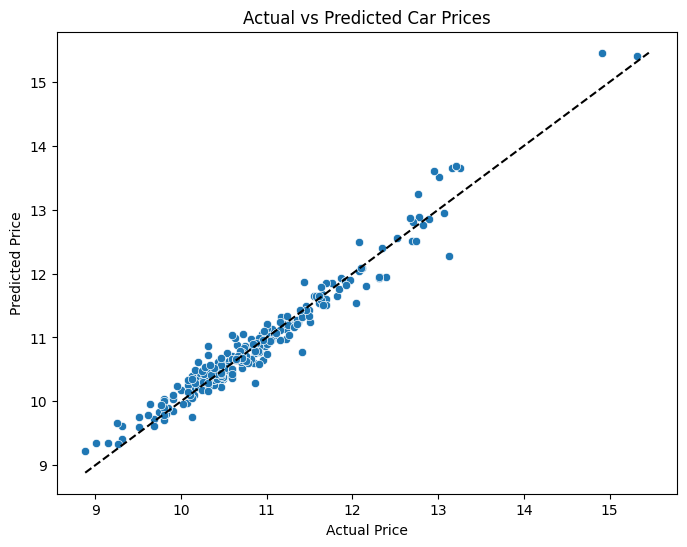

In [ ]:
# Initialize the figure size for the actual vs. predicted price plot
plt.figure(figsize=(8, 6))

# Plot actual vs. predicted values to visually assess prediction accuracy
sns.scatterplot(
    x=y_test,
    y=tuned_pred
)

# Determine the minimum and maximum range across actual and predicted values for the diagonal reference line
min_value = min(y_test.min(), tuned_pred.min())
max_value = max(y_test.max(), tuned_pred.max())

# Draw a 45-degree dashed reference line representing perfect predictions (where Actual == Predicted)
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="black"
)

# Add descriptive labels and title to complete the chart
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

# Render the visualization
plt.show()


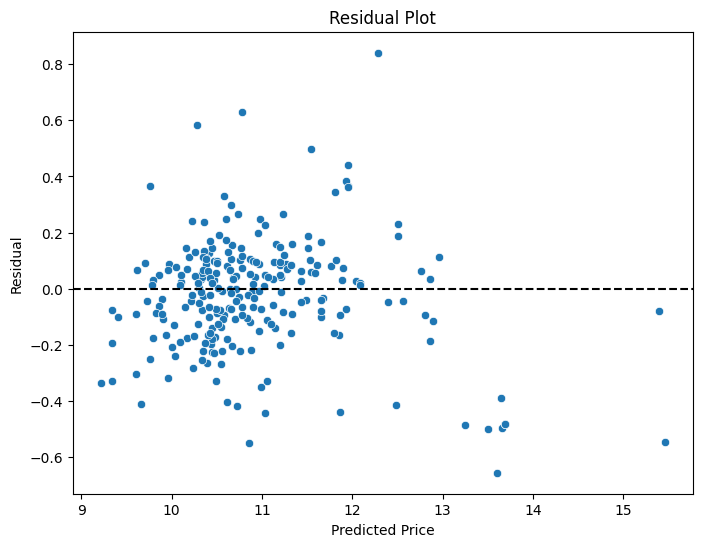

In [ ]:
# Calculate residuals (differences between actual test values and predicted values)
residuals = y_test - tuned_pred

# Initialize figure size for the residual analysis scatter plot
plt.figure(figsize=(8, 6))

# Plot residuals against predicted prices to inspect for variance homoscedasticity and systematic bias
sns.scatterplot(
    x=tuned_pred,
    y=residuals
)

# Draw a horizontal baseline at zero where predicted values perfectly match actual values
plt.axhline(0, linestyle="--", color="Black")

# Set axis labels and chart title
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

# Render the residual plot
plt.show()


In [ ]:
# Extract the fitted preprocessor step from the best tuned pipeline
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Extract the trained Random Forest model from the pipeline
model = best_model.named_steps["model"]

# Retrieve post-transformation feature names including one-hot encoded dummy variables
feature_names = preprocessor_fitted.get_feature_names_out()

# Extract Gini importance / impurity reduction scores for each feature
importance = model.feature_importances_

# Create a DataFrame matching feature names with their importance scores, sorted highest to lowest
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(
    "importance",
    ascending=False
) 

# Display the top 20 most important features driving car price predictions
feature_importance.head(20)


,feature,importance
0,num__horsepower,0.123400
2,num__torque,0.109170
7,num__acceleration_0_100,0.098949
1,num__total_speed,0.082090
3,num__engine_cc,0.075316
13,cat__company_names_Bugatti,0.033259
1590,cat__cc_battery_capacity_7993 cc,0.032915
1312,cat__engines_V12,0.031108
1261,cat__engines_8.0L Quad-Turbo W16,0.021212
1626,cat__seats_2,0.019903


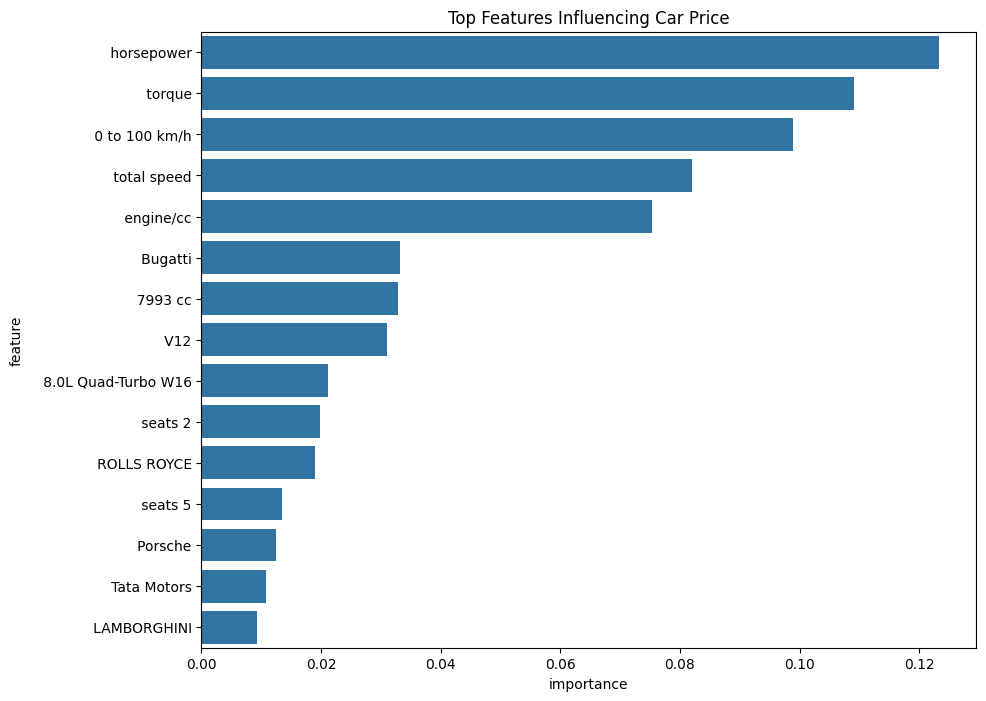

In [ ]:
# Select top 15 features and clean up technical column prefixes/names for clean, human-readable labels
plot_df = feature_importance.head(15).copy()
plot_df['feature'] = (
    plot_df['feature']
    .str.replace(r'^(num_|cat_)', '', regex=True)
    .str.replace('_', ' ')
    .str.replace('company names', ' ')
    .str.replace('cc battery capacity', '')
    .str.replace('engines', ' ')
    .str.replace('acceleration 0 100', '0 to 100 km/h')
    .str.replace('engine cc', 'engine/cc')
)

# Set figure canvas dimensions for the bar chart
plt.figure(figsize=(10, 8))

# Create horizontal bar plot showing relative feature importance weights
sns.barplot(
    data=plot_df,
    x="importance",
    y="feature"
)

# Add title to the feature importance plot
plt.title("Top Features Influencing Car Price")

# Render the bar plot
plt.show()


In [ ]:
# Create a working copy of test features to analyze model predictions against actual market prices
test_results = X_test.copy()

# Append actual and predicted prices to evaluate car-level prediction discrepancies
test_results["actual_price"] = y_test
test_results["predicted_price"] = tuned_pred

# Calculate price difference (actual price - predicted price) to quantify over/under-pricing
test_results["price_difference"] = (
    test_results["actual_price"]
    - test_results["predicted_price"]
)

# Group by automaker/brand to calculate average brand premium (excess value not explained by base specs)
brand_premium = (
    test_results
    .groupby("company_names")["price_difference"]
    .mean()
    .sort_values(ascending=False)
)

# Display automakers ranked by their brand premium
brand_premium


company_names
VOLVO                0.265930
MERCEDES             0.213312
Porsche              0.095037
Tesla                0.063572
BMW                  0.060159
Volvo                0.056659
Kia                  0.038720
Jaguar Land Rover    0.020233
Mitsubishi           0.018463
Volkswagen           0.017206
Peugeot              0.013462
Acura                0.004535
TOYOTA               0.002779
AUDI                 0.002409
KIA                  0.000062
Ford                -0.004669
Jeep                -0.008537
Nissan              -0.016214
GMC                 -0.025857
ROLLS ROYCE         -0.030451
Toyota              -0.092985
Chevrolet           -0.112652
HYUNDAI             -0.125551
Mazda               -0.126187
HONDA               -0.169644
Cadillac            -0.187597
Tata Motors         -0.215976
LAMBORGHINI         -0.292304
Bugatti             -0.312572
FERRARI             -0.483442
NISSAN              -0.495983
Name: price_difference, dtype: float64

In [ ]:
# List evaluated machine learning models and record their finalized benchmark metric scores
models = ['Random Forest', 'Gradient Boosting', 'Linear Regression', 'Baseline']
mae_scores = [0.151204, 0.179870, 0.185824, 0.692459]
rmse_scores = [0.212461, 0.248649, 0.274746, 0.981202]
r2_scores = [0.950165, 0.931743, 0.916664, -0.062894] 

# Define X-axis positions and bar width for grouped bar chart visualization
x = np.arange(len(models))
width = 0.35


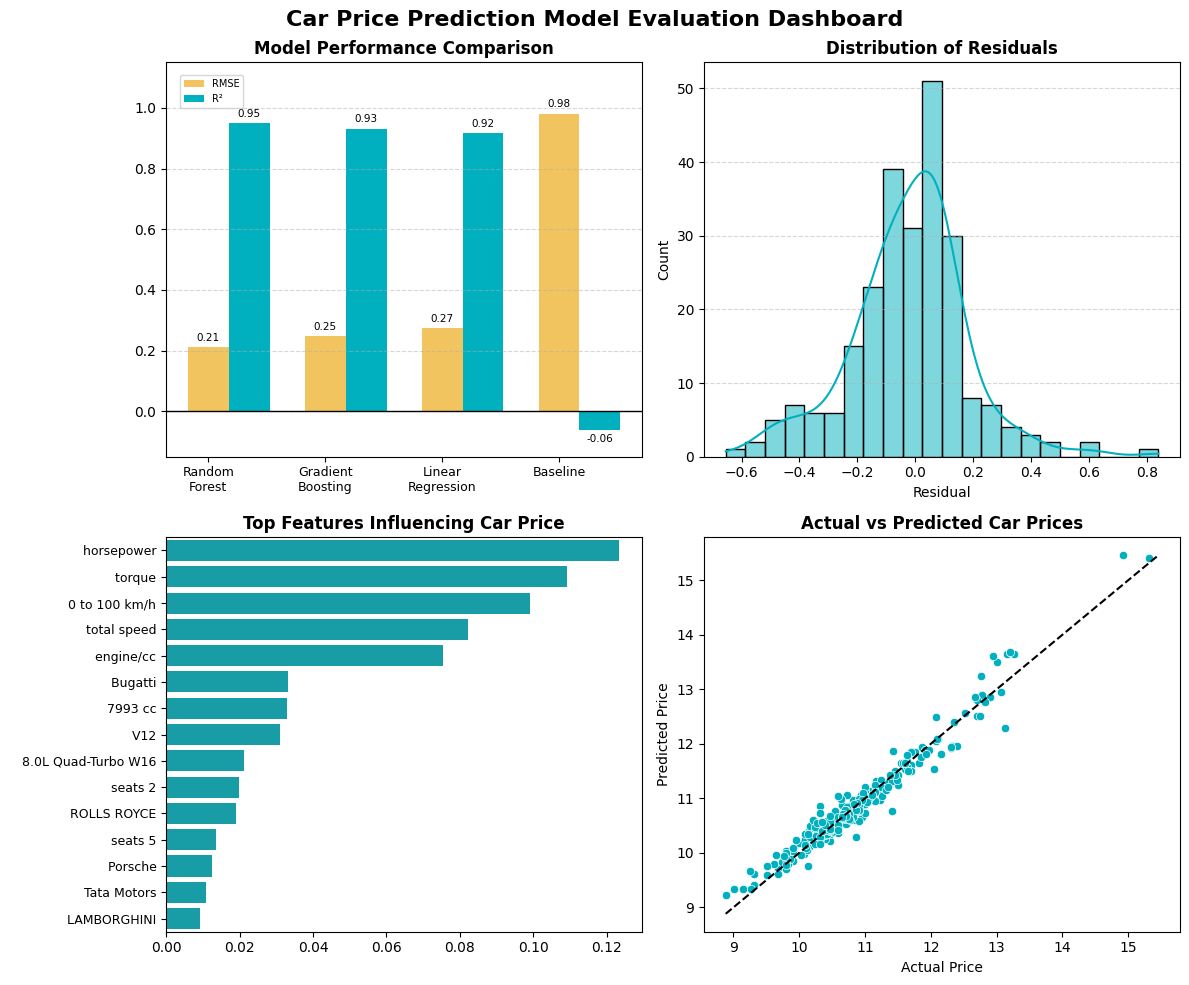

In [ ]:
# Create a 2x2 multi-panel figure grid for comprehensive model evaluation
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Format model names with line breaks to fit nicely on the horizontal X-axis
clean_models = [name.replace(" ", "\n") for name in models]

# Plot side-by-side bars for RMSE (error) and R² (accuracy) scores across models
rects2 = axs[0, 0].bar(x,         rmse_scores, width, label='RMSE', color='#f2c45f')
rects3 = axs[0, 0].bar(x + width, r2_scores, width, label='R²', color='#00b0be')

# Configure subplot title, tick positions, and centered horizontal labels
axs[0, 0].set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(clean_models, rotation=0, ha='center', fontsize=9)

# Position the legend, zero reference line, and background gridlines
axs[0, 0].legend(fontsize=7, loc='upper left', bbox_to_anchor=(0.02, 0.98))
axs[0, 0].axhline(0, color='black', linewidth=1)
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

# Annotate each bar with its rounded numerical value and set Y-axis boundaries
axs[0, 0].bar_label(rects2, padding=3, fmt='%.2f', fontsize=7.5)
axs[0, 0].bar_label(rects3, padding=3, fmt='%.2f', fontsize=7.5)
axs[0, 0].set_ylim(-0.15, 1.15)


# Plot histogram with Kernel Density Estimate (KDE) to inspect error normality and symmetry
sns.histplot(x=residuals, kde=True, color='#00b0be', ax=axs[0, 1]) 
axs[0, 1].set_xlabel("Residual")
axs[0, 1].set_ylabel("Count")
axs[0, 1].set_title("Distribution of Residuals", fontsize=12, fontweight='bold')
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.5)


# Plot horizontal bar chart ranking the top 15 most important features
sns.barplot(data=plot_df.head(15), x="importance", y="feature", ax=axs[1, 0], color='#00b0be')
axs[1, 0].set_title("Top Features Influencing Car Price", fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel("")
axs[1, 0].set_ylabel("")
axs[1, 0].tick_params(axis='y', labelsize=9) 


# Plot actual vs. predicted values for the tuned Random Forest model
sns.scatterplot(x=y_test, y=tuned_pred, ax=axs[1, 1], color='#00b0be')

# Draw diagonal 45-degree reference line representing perfect model predictions
min_value = min(y_test.min(), tuned_pred.min())
max_value = max(y_test.max(), tuned_pred.max())
axs[1, 1].plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black")

# Configure axis labels and title for the scatter plot
axs[1, 1].set_xlabel("Actual Price")
axs[1, 1].set_ylabel("Predicted Price")
axs[1, 1].set_title("Actual vs Predicted Car Prices", fontsize=12, fontweight='bold')


# Set overarching dashboard title and adjust layout spacing
fig.suptitle("Car Price Prediction Model Evaluation Dashboard", fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()
